<a href="https://colab.research.google.com/github/roseal3tb/IT326/blob/main/final_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Prediction Analysis **

# 1- Problem

The primary objective of this project is to develop predictive models to classify patients based on their risk of heart disease using medical indicators. Heart disease is a leading cause of mortality globally, and early detection is crucial for improving survival rates. By applying data mining, we aim to provide actionable insights for healthcare professionals to enhance prevention strategies.

# 2- Data Mining Task

The problem is formalized into two main tasks:
• Classification: Building a model (Decision Tree) to predict whether a patient has heart disease (Class 1) or not (Class 0).
• Clustering: Applying unsupervised learning (K-Means) to group patients into distinct profiles to uncover hidden patterns in medical characteristics.

# 3- Data

The dataset was obtained from Kaggle (Heart Failure Prediction Dataset).
• Size: 918 rows (instances) and 12 columns.
• Target Distribution: 508 patients with heart disease (55%) and 410 patients without heart disease (45%).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectKBest, f_classif
import pickle

df = pd.read_csv('/content/heart.csv')

data = pd.read_csv('/content/heart.csv')
num_attributes = data.shape[1]
num_object = data.shape[0]
attribute_types = data.dtypes.to_frame( name = 'Data Types')
class_name = data.columns[-1]
class_label = data.columns[-1]

print(f"\033[1mGeneral iformation:\n")
print(f"\033[1mNumber of attributes:\033[0m {num_attributes}\n")
print(f"\033[1mNumber of objects:\033[0m {num_object}\n")
print(f"\033[1mClass lable:\033[0m {class_label}\n")
print(f"\033[1mAttribute types:\033[0m")
print(attribute_types)
import seaborn as sns
import matplotlib.pyplot as plt

# Load the original dataset (before preprocessing)
df = pd.read_csv("/content/heart.csv")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7,4)

# 1) Show first few rows of the dataset
print("Dataset Preview:")
display(df.head())

# 2) Structure of dataset: rows, columns, types
print("\nDataset Info:")
print(df.info())

General iformation:

Number of attributes: 12

Number of objects: 918

Class lable: HeartDisease

Attribute types:
               Data Types
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
Dataset Preview:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


# 4- Data Preprocessing

The following tasks were applied to the raw dataset:
• Cleaning: No missing values were found.
• Outlier Removal: Applied using the Interquartile Range (IQR) method.
• Normalization: Numerical features were scaled using Min-Max scaling.
• Encoding: Categorical variables (Sex, ChestPainType, etc.) were converted using Label Encoding.

Data After Preprocessing:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,OldpeakLevel
0,0.244898,1,1,0.70,0.479270,0.0,1,0.788732,0,0.295455,2,0.0,Young,Low
1,0.428571,0,2,0.80,0.298507,0.0,1,0.676056,0,0.409091,1,1.0,Middle,Medium
2,0.183673,1,1,0.65,0.469320,0.0,2,0.267606,0,0.295455,2,0.0,Young,Low
3,0.408163,0,0,0.69,0.354892,0.0,1,0.338028,1,0.465909,1,1.0,Middle,Medium
4,0.530612,1,2,0.75,0.323383,0.0,1,0.436620,0,0.295455,2,0.0,Middle,Low



Summary Statistics:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,0.520630,0.789760,0.781046,0.661983,0.329684,0.233115,0.989107,0.540911,0.404139,0.396291,1.361656,0.553377
std,0.192502,0.407701,0.956519,0.092571,0.181400,0.423046,0.631671,0.179298,0.490992,0.121201,0.607056,0.497414
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.387755,1.000000,0.000000,0.600000,0.287313,0.000000,1.000000,0.422535,0.000000,0.295455,1.000000,0.000000
50%,0.530612,1.000000,0.000000,0.650000,0.369818,0.000000,1.000000,0.549296,0.000000,0.363636,1.000000,1.000000
75%,0.653061,1.000000,2.000000,0.700000,0.442786,0.000000,1.000000,0.676056,1.000000,0.465909,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000


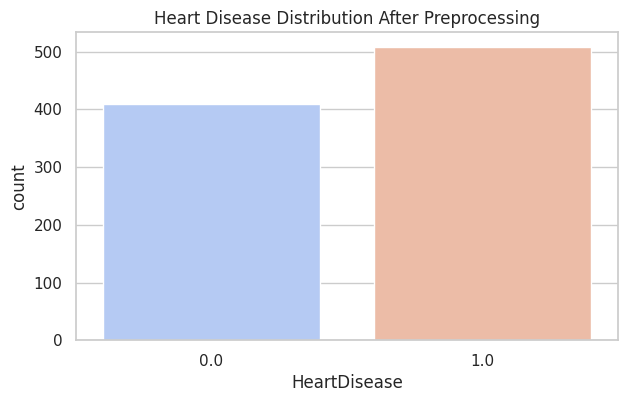

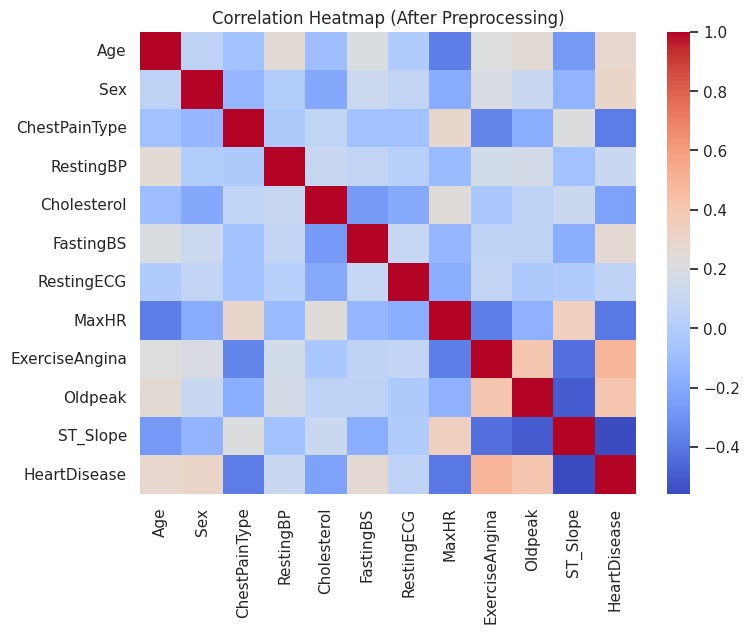

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("/content/sample_data/Preprocessed_data.csv")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7,4)


print("Data After Preprocessing:")
display(df.head())


print("\nSummary Statistics:")
display(df.describe())


plt.figure()
sns.countplot(x="HeartDisease", data=df, palette="coolwarm")
plt.title("Heart Disease Distribution After Preprocessing")
plt.show()


plt.figure(figsize=(8,6))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (After Preprocessing)")
plt.show()

# 5- Data Mining Technique

• Classification: Decision Tree Classifier from sklearn.tree. This technique was chosen for its interpretability through visual decision rules.
• Clustering: K-Means Clustering from sklearn.cluster. This was used to segment patients into groups based on similarity across medical features.

# 6- Evaluation and Comparison

For Classification (Decision Tree):
The performance was compared using Gini Index and Information Gain (Entropy) across three partitions:

--- Generating Confusion Matrices ---


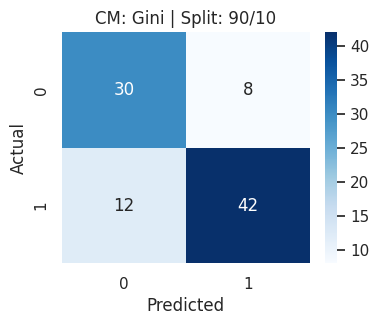

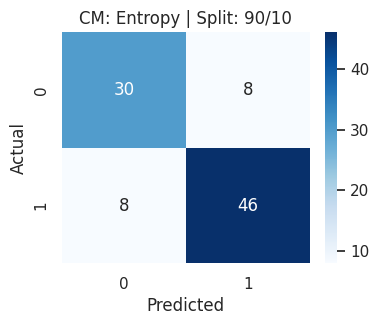

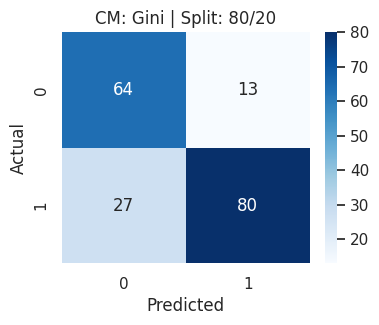

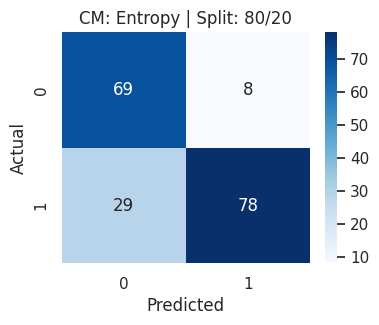

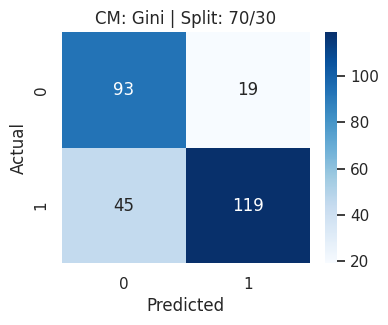

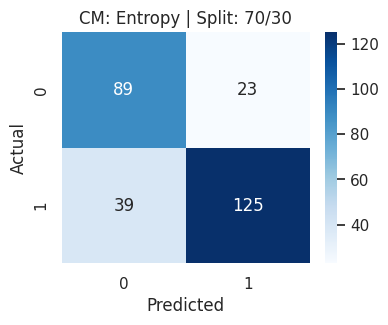


--- Final Accuracy Table ---
Split      70% Training  80% Training  90% Training
Criterion                                          
entropy        0.775362      0.798913      0.826087
gini           0.768116      0.782609      0.782609


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Assuming X and y are already defined from your preprocessing
# X = Preprocessed features, y = Target (HeartDisease)

splits = [0.10, 0.20, 0.30]
criteria = ['gini', 'entropy']
all_results = []

print("--- Generating Confusion Matrices ---")

for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split, random_state=42)
    for crit in criteria:
        # Build Model
        model = DecisionTreeClassifier(criterion=crit, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate Accuracy
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        all_results.append({
            'Split': f"{int((1-split)*100)}% Training",
            'Testing Set': f"{int(split*100)}%",
            'Criterion': crit,
            'Accuracy': acc
        })

        # Plot Confusion Matrix
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"CM: {crit.capitalize()} | Split: {int((1-split)*100)}/{int(split*100)}")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

# Display Final Table
res_df = pd.DataFrame(all_results)
pivot_table = res_df.pivot(index='Criterion', columns='Split', values='Accuracy')
print("\n--- Final Accuracy Table ---")
print(pivot_table)


We evaluated the K-Means algorithm for K=2, K=3, and K=4. Based on the Majority Rule and the Average Silhouette Width, K=2 is identified as the optimal number of clusters, providing the clearest separation between patient groups. While the within-cluster sum of squares (WCSS) decreases as K increases, the silhouette score confirms that a two-cluster solution is the most statistically significant for this dataset.